In [87]:
import pandas as pd
import numpy as np
import sys
sys.path.append('../kaggle_prediction_library/') 
import preprocess
import feature_engineering
import submission
import validation
from sklearn.model_selection import train_test_split

# from hyperopt import tpe, fmin, Trials
# import hyperopt.hp as hp

from sklearn.linear_model import LogisticRegression
from sklearn.linear_model import LogisticRegressionCV
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.metrics import log_loss
from sklearn.feature_selection import chi2
from sklearn.metrics import r2_score
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import brier_score_loss
from sklearn.pipeline import make_pipeline



In [88]:
to_predict_mens = pd.read_csv("to_predict_mens_s16.csv")

In [89]:
to_predict_mens[to_predict_mens.Season == 2025].sort_values(by="t1_adj_margin", ascending=False)[['t1_TeamName', 't1_adj_margin']].drop_duplicates().head(20)

,t1_TeamName,t1_adj_margin
27199,Duke,41.114815
9125,Auburn,39.444047
37493,Houston,36.583156
31238,Florida,34.562405
65660,Tennessee,32.742752
35160,Gonzaga,31.077055
3936,Alabama,29.260605
66076,Texas Tech,29.225481
67812,VCU,28.566672
6482,Arizona,28.190626


In [90]:
to_predict_mens[to_predict_mens.ID == '2025_1166_1257']

,Unnamed: 0,type,ID,Pred,Season,Team1,Team2,Outcome,Gender,margin,...,t1_top3_USG_gini,t1_top8_BPM_weighted_mean,t2_top8_TO_stdev,t2_top5_PRPG!_median,t2_top3_DR_median,t2_top5_STL_cv,t2_top3_Min%_median,t2_top8_TS_gini,t2_top3_USG_gini,t2_top8_BPM_weighted_mean
22558,22558,Prediction,2025_1166_1257,0.5,2025,1166,1257,NaN,M,NaN,...,0.047887,4.385489,4.595905,3.6,10.9,0.577651,82.3,0.068758,0.074612,4.870659


### Prepare data 

In [91]:
def prepare_data(to_predict_mens, season):

    to_predict_mens_first_round_train = to_predict_mens[
                                                        (to_predict_mens["GameRound"] == 1) &
                                                        (to_predict_mens.Season < season)
                                                        & (to_predict_mens.Season >= 2008)
                                                        ].copy()
    
    to_predict_mens_train = to_predict_mens[(to_predict_mens.Season < season)
                                            & (to_predict_mens.Season >= 2008)].copy()

    to_predict_mens_first_round_test = to_predict_mens[
                                                    # (to_predict_mens.Season == season) &
                                                    (to_predict_mens.type == "Prediction")
                                                    & (to_predict_mens.GameRound == 1)
                                                    # & (to_predict_mens.final_odds.notnull())
                                                    ].copy()

    to_predict_mens_other_rounds_test = to_predict_mens[
                                                    # (to_predict_mens.Season == season) &
                                                    (to_predict_mens.GameRound > 1)
                                                    & (to_predict_mens.type == "Prediction")
                                                    ].copy()

    to_predict_mens_missing_games = to_predict_mens[
                                                 ( 
                                                     (to_predict_mens.GameRound.isna())
                                                     | (to_predict_mens.GameRound == 0)
                                                     )
                                                & (to_predict_mens.type == "Prediction")
                                                ]
    
    return to_predict_mens_first_round_train, to_predict_mens_train, to_predict_mens_first_round_test, to_predict_mens_other_rounds_test, to_predict_mens_missing_games
    


### Statistics Model Training

In [92]:
def train_statistics_model(to_predict_mens_train, statistics_features):

    best_params = {"C": .1}
    model = LogisticRegression(**best_params)
    pipeline = make_pipeline(StandardScaler(), model)
    statistics_model = pipeline.fit(to_predict_mens_train[statistics_features], to_predict_mens_train["Outcome"])

    return statistics_model


### Full Pipeline

In [93]:
SEASON = 2025

statistics_model_full_features = [   't1_top8_BPM_weighted_mean', 't2_top8_BPM_weighted_mean',
    't1_top8_TO_stdev', 't2_top8_TO_stdev',
    't1_top5_PRPG!_median', 't2_top5_PRPG!_median',
    't1_top3_DR_median', 't2_top3_DR_median',
    't1_top5_STL_cv', 't2_top5_STL_cv',
    't1_top3_Min%_median', 't2_top3_Min%_median',
    't1_top8_TS_gini', 't2_top8_TS_gini',
    't1_top3_USG_gini', 't2_top3_USG_gini',
    # 't1_OrdinalRank', 't2_OrdinalRank',
    # 't1_adj_margin', 't2_adj_margin', 
    ]

statistics_model_first_round_features = ['t1_top8_BPM_weighted_mean', 't2_top8_BPM_weighted_mean',
    't1_top8_TO_stdev', 't2_top8_TO_stdev',
    't1_top5_PRPG!_median', 't2_top5_PRPG!_median',
    't1_top3_DR_median', 't2_top3_DR_median',
    't1_top5_STL_cv', 't2_top5_STL_cv',
    't1_top3_Min%_median', 't2_top3_Min%_median',
    't1_top8_TS_gini', 't2_top8_TS_gini',
    't1_top3_USG_gini', 't2_top3_USG_gini',
    't1_OrdinalRank', 't2_OrdinalRank'
    ,]


# get data
to_predict_mens_first_round_train, to_predict_mens_train, to_predict_mens_first_round_test, to_predict_mens_other_rounds_test, to_predict_mens_missing_games= prepare_data(to_predict_mens, SEASON)



In [94]:
# train
statistics_model_full = train_statistics_model(to_predict_mens_train, statistics_model_full_features)
statistics_model_first_round = train_statistics_model(to_predict_mens_first_round_train, statistics_model_first_round_features)

In [95]:
for feature in statistics_model_full_features:
    to_predict_mens_other_rounds_test[feature] = to_predict_mens_other_rounds_test[feature].fillna(to_predict_mens_train[feature].mean())

In [96]:
# inference - this is the code we should run
pred_proba = statistics_model_first_round.predict_proba(to_predict_mens_first_round_test[statistics_model_first_round_features].copy())[:,1]
to_predict_mens_first_round_test["Pred"] = pred_proba

pred_proba = statistics_model_full.predict_proba(to_predict_mens_other_rounds_test[statistics_model_full_features].copy())[:,1]
to_predict_mens_other_rounds_test["Pred"] = pred_proba

mens_sub_tmp = pd.concat([to_predict_mens_first_round_test,
        to_predict_mens_other_rounds_test], axis=0)

mens_sub_actual_games = mens_sub_tmp[["ID", "Pred"]]

mens_sub_actual_not_games = to_predict_mens_missing_games[["ID", "Pred"]]

mens_sub = pd.concat([mens_sub_actual_games,
        mens_sub_actual_not_games], axis=0)


In [11]:
mens_sub_actual_games.to_csv("mens_sub_actual_games_s16.csv", index=False)

### Check Probs

In [97]:
mens_sub_actual_games = mens_sub_actual_games.merge(to_predict_mens[["ID", "t1_TeamName", "t2_TeamName",
                                         't1_Seed', 't2_Seed',
                                         'GameRound']], how="left", on="ID")

In [98]:
sweet_16_teams = ['Auburn', 'Michigan', 'Mississippi',
                  'Michigan St', 'Florida', 'Maryland',
                  'Texas Tech', 'Arkansas', 'Duke',
                  'Arizona', 'BYU', 'Alabama', 'Houston',
                  'Purdue', 'Kentucky', 'Tennessee']

games = mens_sub_actual_games[
    ((mens_sub_actual_games.t1_TeamName.isin(sweet_16_teams))
    & (mens_sub_actual_games.t2_TeamName.isin(sweet_16_teams)))
    & (mens_sub_actual_games.GameRound > 2)

    ]

In [99]:
mapping_dict = {1:1, 2:2, 3:3, 4:6, 5:12, 6:24}
games['round_points'] = games["GameRound"].map(mapping_dict)

/var/folders/h5/f91pbgmj0rj6v0ls3y8zc5l40000gn/T/ipykernel_55125/2966514964.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  games['round_points'] = games["GameRound"].map(mapping_dict)


In [100]:
games["t1_ev"] = (games["t1_Seed"] * games["Pred"] * games["round_points"]) 
games["t2_ev"] = (games["t2_Seed"] * (1-games["Pred"]) * games["round_points"])
games["abs_net_ev"] = np.abs((games["t1_Seed"] * games["Pred"] * games["round_points"]) - (games["t2_Seed"] * (1-games["Pred"]) * games["round_points"]))

/var/folders/h5/f91pbgmj0rj6v0ls3y8zc5l40000gn/T/ipykernel_55125/4001649472.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  games["t1_ev"] = (games["t1_Seed"] * games["Pred"] * games["round_points"])
/var/folders/h5/f91pbgmj0rj6v0ls3y8zc5l40000gn/T/ipykernel_55125/4001649472.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  games["t2_ev"] = (games["t2_Seed"] * (1-games["Pred"]) * games["round_points"])
/var/folders/h5/f91pbgmj0rj6v0ls3y8zc5l40000gn/T/ipykernel_55125/4001649472.py:3: SettingWithCopyWar

In [101]:
games["t2_Pred"] = 1 - games["Pred"]

/var/folders/h5/f91pbgmj0rj6v0ls3y8zc5l40000gn/T/ipykernel_55125/189514504.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  games["t2_Pred"] = 1 - games["Pred"]


In [102]:
games["t1_points"] = games["round_points"] * games["t1_Seed"]
games["t2_points"] = games["round_points"] * games["t2_Seed"]

/var/folders/h5/f91pbgmj0rj6v0ls3y8zc5l40000gn/T/ipykernel_55125/2597649641.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  games["t1_points"] = games["round_points"] * games["t1_Seed"]
/var/folders/h5/f91pbgmj0rj6v0ls3y8zc5l40000gn/T/ipykernel_55125/2597649641.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  games["t2_points"] = games["round_points"] * games["t2_Seed"]


In [106]:
games[games.GameRound == 4].sort_values(by="abs_net_ev", ascending=False)[[
    't1_TeamName', 't2_TeamName', 'Pred', 't2_Pred', 't1_ev', 't2_ev', 'abs_net_ev',
    't1_points', 't2_points'
]]

,t1_TeamName,t2_TeamName,Pred,t2_Pred,t1_ev,t2_ev,abs_net_ev,t1_points,t2_points
379,Arkansas,Maryland,0.226704,0.773296,13.602269,18.559092,4.956823,60.0,24.0
1725,Michigan,Michigan St,0.397887,0.602113,11.936614,7.225354,4.711260,30.0,12.0
445,Auburn,Mississippi,0.755009,0.244991,4.530053,8.819683,4.289630,6.0,36.0
1260,Houston,Kentucky,0.894850,0.105150,5.369101,1.892696,3.476405,6.0,18.0
1448,Kentucky,Purdue,0.489933,0.510067,8.818795,12.241606,3.422811,18.0,24.0
1287,Houston,Tennessee,0.854229,0.145771,5.125371,1.749257,3.376114,6.0,12.0
104,Alabama,Arizona,0.575336,0.424664,6.904032,10.191935,3.287903,12.0,24.0
2075,Purdue,Tennessee,0.417550,0.582450,10.021205,6.989397,3.031808,24.0,12.0
1058,Florida,Texas Tech,0.630783,0.369217,3.784696,6.645913,2.861217,6.0,18.0
598,BYU,Duke,0.203757,0.796243,7.335244,4.777459,2.557784,36.0,6.0


In [104]:
games[(games.t1_TeamName == 'Duke')
       | (games.t2_TeamName == 'Duke')].sort_values(by="abs_net_ev", ascending=False)[[
    't1_TeamName', 't2_TeamName', 'Pred', 't2_Pred', 't1_ev', 't2_ev', 'abs_net_ev',
    't1_points', 't2_points'
]]

,t1_TeamName,t2_TeamName,Pred,t2_Pred,t1_ev,t2_ev,abs_net_ev,t1_points,t2_points
935,Duke,Maryland,0.713197,0.286803,17.116727,27.533091,10.416364,24.0,96.0
959,Duke,Texas Tech,0.657260,0.342740,15.774249,24.677253,8.903004,24.0,72.0
939,Duke,Michigan St,0.778561,0.221439,18.685470,10.629060,8.056410,24.0,48.0
424,Auburn,Duke,0.350833,0.649167,8.419984,15.580016,7.160032,24.0,24.0
930,Duke,Kentucky,0.853016,0.146984,10.236196,5.291413,4.944782,12.0,36.0
956,Duke,Tennessee,0.799848,0.200152,9.598178,4.803644,4.794534,12.0,24.0
364,Arkansas,Duke,0.105460,0.894540,25.310446,21.468955,3.841490,240.0,24.0
950,Duke,Purdue,0.847895,0.152105,10.174737,7.301052,2.873685,12.0,48.0
598,BYU,Duke,0.203757,0.796243,7.335244,4.777459,2.557784,36.0,6.0
926,Duke,Houston,0.405449,0.594551,4.865382,7.134618,2.269236,12.0,12.0


In [77]:
# Compute variance (σ²)
games['t1_variance'] = games['Pred'] * (games['t1_points'] - games['t1_ev'])**2 + (1 - games['Pred']) * (games['t1_ev'])**2

# Compute standard deviation (σ)
games['t1_std_dev'] = np.sqrt(games['t1_variance'])

# Compute Sharpe-like ratio
games['t1_sharpe_ratio'] = games['t1_ev'] / games['t1_std_dev']


# Compute variance (σ²)
games['t2_variance'] = games['Pred'] * (games['t2_points'] - games['t2_ev'])**2 + (1 - games['t2_Pred']) * (games['t2_ev'])**2

# Compute standard deviation (σ)
games['t2_std_dev'] = np.sqrt(games['t2_variance'])

# Compute Sharpe-like ratio
games['t2_sharpe_ratio'] = games['t2_ev'] / games['t2_std_dev']


In [81]:
games[games.GameRound == 3].sort_values(by="t1_sharpe_ratio", ascending=False)[[
    't1_TeamName', 't2_TeamName', 'Pred', 't2_Pred', 't1_ev', 't2_ev', 'abs_net_ev', 't1_sharpe_ratio', 't2_sharpe_ratio'
]]

,t1_TeamName,t2_TeamName,Pred,t2_Pred,t1_ev,t2_ev,abs_net_ev,t1_sharpe_ratio,t2_sharpe_ratio
1281,Houston,Purdue,0.891000,0.109000,3.564000,1.743999,1.820001,2.859076,0.128642
443,Auburn,Michigan,0.741963,0.258037,2.967852,5.160738,2.192885,1.695705,0.381343
1034,Florida,Maryland,0.688996,0.311004,2.755983,4.976068,2.220085,1.488419,0.495648
109,Alabama,BYU,0.659483,0.340517,5.275863,8.172412,2.896550,1.391657,0.564954
1757,Michigan St,Mississippi,0.618594,0.381406,4.948756,9.153733,4.204977,1.273531,0.667289
1454,Kentucky,Tennessee,0.407789,0.592211,4.893473,4.737685,0.155789,0.829812,1.289765
302,Arizona,Duke,0.267833,0.732167,4.285333,2.928667,1.356666,0.604822,1.814665
404,Arkansas,Texas Tech,0.184392,0.815608,7.375700,9.787290,2.411590,0.475479,2.271454


In [ ]:
t1 = "Kentucky"
t2 = "Tennessee"

games[
    ((games.t1_TeamName == t1) 
    & (mens_sub_actual_games.t2_TeamName == t2))
    |
    ((mens_sub_actual_games.t1_TeamName == t2) 
    & (mens_sub_actual_games.t2_TeamName == t1))
     ]

,ID,Pred,t1_TeamName,t2_TeamName,t1_Seed,t2_Seed,GameRound
1454,2025_1246_1397,0.407789,Kentucky,Tennessee,3.0,2.0,3.0


In [29]:
1 - 0.407789

0.592211

In [ ]:
# Auburn / Mich -> 0.741963
# Mississippi / Michigan St -> 0.618594
# Florida / Maryland -> .688
# Duke / Arizona -> 0.732167
# Alabama / BYU -> 0.659483
# Houston / Purdue -> 0.891
# Tennessee / Kentucky -> 0.592211


In [34]:
4 * 1 * (.741963) - 4 * 5 * (1-.741963)

-2.1928879999999986

### Sanity Checks

In [180]:
to_predict_mens_first_round_test.shape


(36, 71)

In [181]:
mens_sub_tmp.columns

Index(['Unnamed: 0', 'type', 'ID', 'Pred', 'Season', 'Team1', 'Team2',
       'Outcome', 'Gender', 'margin', 't1_TeamName', 't1_FirstD1Season',
       't1_LastD1Season', 't2_TeamName', 't2_FirstD1Season', 't2_LastD1Season',
       'final_odds', 'GameRound', 't1_FGM', 't1_FGA', 't1_FGM3', 't1_FGA3',
       't1_OR', 't1_Ast', 't1_TO', 't1_Stl', 't1_PF', 't1_FTA', 't1_FTM',
       't1_PointDiff', 't2_FGM', 't2_FGA', 't2_FGM3', 't2_FGA3', 't2_OR',
       't2_Ast', 't2_TO', 't2_Stl', 't2_PF', 't2_FTA', 't2_FTM',
       't2_PointDiff', 't1_OrdinalRank', 't2_OrdinalRank', 't1_Seed',
       't2_Seed', 'seed_diff', 't1_adj_oe', 't1_adj_de', 't1_adj_margin',
       't2_adj_oe', 't2_adj_de', 't2_adj_margin', 't1_final_rank',
       't2_final_rank', 't1_top8_TO_stdev', 't1_top5_PRPG!_median',
       't1_top3_DR_median', 't1_top5_STL_cv', 't1_top3_Min%_median',
       't1_top8_TS_gini', 't1_top3_USG_gini', 't1_top8_BPM_weighted_mean',
       't2_top8_TO_stdev', 't2_top5_PRPG!_median', 't2_top3_DR_m

In [270]:
mens_sub_tmp[mens_sub_tmp.GameRound == 1][["Pred", "Outcome", 't1_TeamName', 't2_TeamName', "GameRound"]].tail(15)

,Pred,Outcome,t1_TeamName,t2_TeamName,GameRound
39165,0.519594,NaN,Illinois,Xavier,1.0
40643,0.884430,NaN,Iowa St,Lipscomb,1.0
43334,0.818259,NaN,Kentucky,Troy,1.0
44376,0.561980,NaN,Liberty,Oregon,1.0
47547,0.563697,NaN,Marquette,New Mexico,1.0
49710,0.601916,NaN,Michigan,UC San Diego,1.0
50141,0.453104,NaN,Mississippi,North Carolina,1.0
50187,0.675967,NaN,Mississippi,San Diego St,1.0
51416,0.076269,NaN,Montana,Wisconsin,1.0
54202,0.093954,NaN,NE Omaha,St John's,1.0


In [271]:
# Round 1 correctness
round1_correctness = mens_sub_tmp[mens_sub_tmp.GameRound == 1][["Pred", "Outcome", 't1_TeamName', 't2_TeamName', 
                                                                "t1_Seed", "t2_Seed", "GameRound"]]
round1_correctness["Outcome_Pred"] = np.where(round1_correctness.Pred > .5, 1, 0 )
round1_correctness["Correct"] = np.where(round1_correctness["Outcome"] == round1_correctness["Outcome_Pred"], 1, 0)
round1_correctness["Correct"].mean()

0.0

In [272]:
round1_correctness[(
   (  (round1_correctness.t1_Seed >= 10) & (round1_correctness.Pred >= .20) )
)
].head(50)

,Pred,Outcome,t1_TeamName,t2_TeamName,t1_Seed,t2_Seed,GameRound,Outcome_Pred,Correct
7873,0.241533,NaN,Arkansas,Kansas,10.0,7.0,1.0,0,0
21043,0.604794,NaN,Colorado St,Memphis,12.0,5.0,1.0,1,0
26443,0.546917,NaN,Drake,Missouri,11.0,6.0,1.0,1,0
36821,0.216739,NaN,High Point,Purdue,13.0,4.0,1.0,0,0
44376,0.561980,NaN,Liberty,Oregon,12.0,5.0,1.0,1,0


In [284]:
team_name = "Nebraska"
mens_sub_tmp.columns.unique()

Index(['Unnamed: 0', 'type', 'ID', 'Pred', 'Season', 'Team1', 'Team2',
       'Outcome', 'Gender', 'margin', 't1_TeamName', 't1_FirstD1Season',
       't1_LastD1Season', 't2_TeamName', 't2_FirstD1Season', 't2_LastD1Season',
       'final_odds', 'GameRound', 't1_FGM', 't1_FGA', 't1_FGM3', 't1_FGA3',
       't1_OR', 't1_Ast', 't1_TO', 't1_Stl', 't1_PF', 't1_FTA', 't1_FTM',
       't1_PointDiff', 't2_FGM', 't2_FGA', 't2_FGM3', 't2_FGA3', 't2_OR',
       't2_Ast', 't2_TO', 't2_Stl', 't2_PF', 't2_FTA', 't2_FTM',
       't2_PointDiff', 't1_OrdinalRank', 't2_OrdinalRank', 't1_Seed',
       't2_Seed', 'seed_diff', 't1_adj_oe', 't1_adj_de', 't1_adj_margin',
       't2_adj_oe', 't2_adj_de', 't2_adj_margin', 't1_final_rank',
       't2_final_rank', 't1_top8_TO_stdev', 't1_top5_PRPG!_median',
       't1_top3_DR_median', 't1_top5_STL_cv', 't1_top3_Min%_median',
       't1_top8_TS_gini', 't1_top3_USG_gini', 't1_top8_BPM_weighted_mean',
       't2_top8_TO_stdev', 't2_top5_PRPG!_median', 't2_top3_DR_m

In [292]:
mens_sub_tmp.sort_values(by='t2_adj_margin', ascending=False).drop_duplicates(subset = 'Team2')[['Team2', 't2_TeamName', 't2_adj_margin']].head(50)

,Team2,t2_TeamName,t2_adj_margin
6412,1181,Duke,41.114815
3863,1120,Auburn,39.444047
34388,1222,Houston,36.583156
21584,1196,Florida,34.562405
4846,1397,Tennessee,32.742752
26375,1211,Gonzaga,31.077055
3489,1104,Alabama,29.260605
65595,1403,Texas Tech,29.225481
21813,1433,VCU,28.566672
3856,1112,Arizona,28.190626


In [191]:
mens_sub_tmp[(mens_sub_tmp.t1_TeamName == "Duke")][statistics_model_full_features]#.iloc[:,0].tolist()

,t1_top8_BPM_weighted_mean,t2_top8_BPM_weighted_mean,t1_top8_TO_stdev,t2_top8_TO_stdev,t1_top5_PRPG!_median,t2_top5_PRPG!_median,t1_top3_DR_median,t2_top3_DR_median,t1_top5_STL_cv,t2_top5_STL_cv,t1_top3_Min%_median,t2_top3_Min%_median,t1_top8_TS_gini,t2_top8_TS_gini,t1_top3_USG_gini,t2_top3_USG_gini,t1_OrdinalRank,t2_OrdinalRank,t1_adj_margin,t2_adj_margin
27031,8.353145,-0.634159,2.357302,7.055627,3.8,1.4,10.5,12.1,0.433588,0.256174,71.7,83.0,0.058566,0.059683,0.107312,0.103340,6.0,25.0,41.114815,-4.988205
26931,8.353145,-0.608000,2.357302,3.256532,3.8,1.1,10.5,12.8,0.433588,0.327109,71.7,79.8,0.058566,0.054264,0.107312,0.092249,6.0,25.0,41.114815,-0.620679
26939,8.353145,7.566371,2.357302,2.042632,3.8,4.1,10.5,10.7,0.433588,0.245574,71.7,78.6,0.058566,0.046457,0.107312,0.073016,6.0,20.0,41.114815,34.562405
26951,8.353145,4.383050,2.357302,4.746166,3.8,2.4,10.5,13.7,0.433588,0.222371,71.7,72.1,0.058566,0.018864,0.107312,0.057325,6.0,25.0,41.114815,21.068689
26954,8.353145,6.364114,2.357302,3.684745,3.8,3.4,10.5,8.5,0.433588,0.181222,71.7,74.4,0.058566,0.045640,0.107312,0.077876,6.0,4.0,41.114815,31.077055
26956,8.353145,2.197587,2.357302,3.019701,3.8,2.0,10.5,11.7,0.433588,0.308811,71.7,71.4,0.058566,0.045073,0.107312,0.085082,6.0,25.0,41.114815,10.738802
26960,8.353145,2.706164,2.357302,1.903287,3.8,3.2,10.5,10.8,0.433588,0.395967,71.7,62.4,0.058566,0.016946,0.107312,0.038647,6.0,25.0,41.114815,8.079373
26963,8.353145,8.555080,2.357302,4.083943,3.8,4.5,10.5,10.3,0.433588,0.230294,71.7,76.9,0.058566,0.040613,0.107312,0.016667,6.0,8.0,41.114815,36.583156
26969,8.353145,5.555258,2.357302,4.818957,3.8,3.4,10.5,11.7,0.433588,0.395238,71.7,73.4,0.058566,0.041594,0.107312,0.135574,6.0,25.0,41.114815,21.937838
26976,8.353145,6.236492,2.357302,4.438028,3.8,3.3,10.5,14.7,0.433588,0.426782,71.7,73.0,0.058566,0.024206,0.107312,0.075643,6.0,7.0,41.114815,26.407113


In [273]:
import matplotlib.pyplot as plt
import numpy as np

def plot_feature_impact(features, values, coefficients, figsize=(10, 6),
                          title="Feature Impact (Value x Coefficient)"):
    """
    Plots the impact of each feature by multiplying its value with its coefficient.

    Parameters:
        features (list of str): Names of the features.
        values (list of float): The values for each feature (e.g., for a given sample).
        coefficients (list of float): The logistic regression coefficients.
        figsize (tuple): Size of the figure.
        title (str): Title for the plot.
    """
    if not (len(features) == len(values) == len(coefficients)):
        raise ValueError("All input lists (features, values, coefficients) must have the same length.")
    
    # Convert to numpy arrays for easy manipulation
    features = np.array(features)
    values = np.array(values)
    coefficients = np.array(coefficients)
    
    # Calculate impact for each feature
    impacts = values * coefficients
    
    # Sort features by the absolute impact in descending order
    sorted_indices = np.argsort(np.abs(impacts))[::-1]
    sorted_features = features[sorted_indices]
    sorted_impacts = impacts[sorted_indices]
    
    # Create colors: blue for positive, red for negative
    colors = ['blue' if impact >= 0 else 'red' for impact in sorted_impacts]
    
    # Plotting
    plt.figure(figsize=figsize)
    bars = plt.barh(sorted_features, sorted_impacts, color=colors)
    plt.xlabel("Impact (Feature Value x Coefficient)")
    plt.title(title)
    plt.axvline(0, color='black', linewidth=1)  # vertical line at zero

    # Annotate each bar with the impact value
    max_impact = np.abs(sorted_impacts).max() if np.abs(sorted_impacts).max() != 0 else 1
    x_offset = 0.02 * max_impact
    for bar in bars:
        width = bar.get_width()
        xpos = width + x_offset if width >= 0 else width - x_offset
        ha = 'left' if width >= 0 else 'right'
        plt.text(xpos, bar.get_y() + bar.get_height()/2, f'{width:.2f}', va='center', ha=ha, color='black')
    
    plt.gca().invert_yaxis()  # highest impact at the top
    plt.tight_layout()
    plt.show()




In [274]:
def analyze_first_round_game(t1_team_name):
    scaler = statistics_model_first_round.named_steps['standardscaler']
    scaled_feature_names = ["scaled_" + feature for feature in statistics_model_first_round_features]
    mens_sub_tmp[scaled_feature_names] = scaler.transform(mens_sub_tmp[statistics_model_first_round_features])
    raw_values_list = mens_sub_tmp[(mens_sub_tmp.t1_TeamName == t1_team_name)][statistics_model_first_round_features].transpose().iloc[:,0].tolist()
    values_list = mens_sub_tmp[(mens_sub_tmp.t1_TeamName == t1_team_name)][scaled_feature_names].transpose().iloc[:,0].tolist()
    coef_list = statistics_model_first_round.named_steps['logisticregression'].coef_.tolist()[0]
    df_analysis = pd.DataFrame(list(zip(coef_list, raw_values_list, values_list)), columns = ["model_coef", "raw_feature_value", 
    "feature_value"])
    df_analysis["feature_name"] = statistics_model_first_round_features
    df_analysis["impact"] = df_analysis.model_coef * df_analysis.feature_value
    df_analysis["abs_impact"] = np.abs(df_analysis["impact"])
    df_analysis.sort_values(by="abs_impact", ascending=False)

    net_weighted_values = sum(x * y for x, y in zip(values_list, coef_list))

    print(f"net weighted value: {net_weighted_values}")

    plot_feature_impact(statistics_model_first_round_features, values_list, coef_list)

    return df_analysis[["feature_name", "raw_feature_value", "feature_value",
                        "model_coef", "impact", "abs_impact"]].sort_values(by="abs_impact", ascending=False)

In [275]:
def analyze_non_first_round_game(t1_team_name, t2_team_name):
    scaler = statistics_model_full.named_steps['standardscaler']
    scaled_feature_names = ["scaled_" + feature for feature in statistics_model_full_features]
    mens_sub_tmp[scaled_feature_names] = scaler.transform(mens_sub_tmp[statistics_model_full_features])
    raw_values_list = mens_sub_tmp[
        (mens_sub_tmp.t1_TeamName == t1_team_name) & (mens_sub_tmp.t2_TeamName == t2_team_name)][statistics_model_full_features].transpose().iloc[:,0].tolist()
    values_list = mens_sub_tmp[(mens_sub_tmp.t1_TeamName == t1_team_name) & (mens_sub_tmp.t2_TeamName == t2_team_name)][scaled_feature_names].transpose().iloc[:,0].tolist()
    coef_list = statistics_model_full.named_steps['logisticregression'].coef_.tolist()[0]
    df_analysis = pd.DataFrame(list(zip(coef_list, raw_values_list, values_list)), columns = ["model_coef", "raw_feature_value", 
    "feature_value"])
    df_analysis["feature_name"] = statistics_model_full_features
    df_analysis["impact"] = df_analysis.model_coef * df_analysis.feature_value
    df_analysis["abs_impact"] = np.abs(df_analysis["impact"])
    df_analysis.sort_values(by="abs_impact", ascending=False)

    net_weighted_values = sum(x * y for x, y in zip(values_list, coef_list))

    print(f"net weighted value: {net_weighted_values}")

    plot_feature_impact(statistics_model_full_features, values_list, coef_list)

    return df_analysis[["feature_name", "raw_feature_value", "feature_value",
                        "model_coef", "impact", "abs_impact"]].sort_values(by="abs_impact", ascending=False)

In [293]:
mens_sub_tmp.sort_values(by='t2_adj_margin', ascending=False).drop_duplicates(subset = 'Team2')[['Team2', 't2_TeamName', 't2_adj_margin', 't2_OrdinalRank']].head(50)

,Team2,t2_TeamName,t2_adj_margin,t2_OrdinalRank
6412,1181,Duke,41.114815,6.0
3863,1120,Auburn,39.444047,5.0
34388,1222,Houston,36.583156,8.0
21584,1196,Florida,34.562405,20.0
4846,1397,Tennessee,32.742752,11.0
26375,1211,Gonzaga,31.077055,4.0
3489,1104,Alabama,29.260605,2.0
65595,1403,Texas Tech,29.225481,25.0
21813,1433,VCU,28.566672,25.0
3856,1112,Arizona,28.190626,9.0


net weighted value: 0.4134549074675875


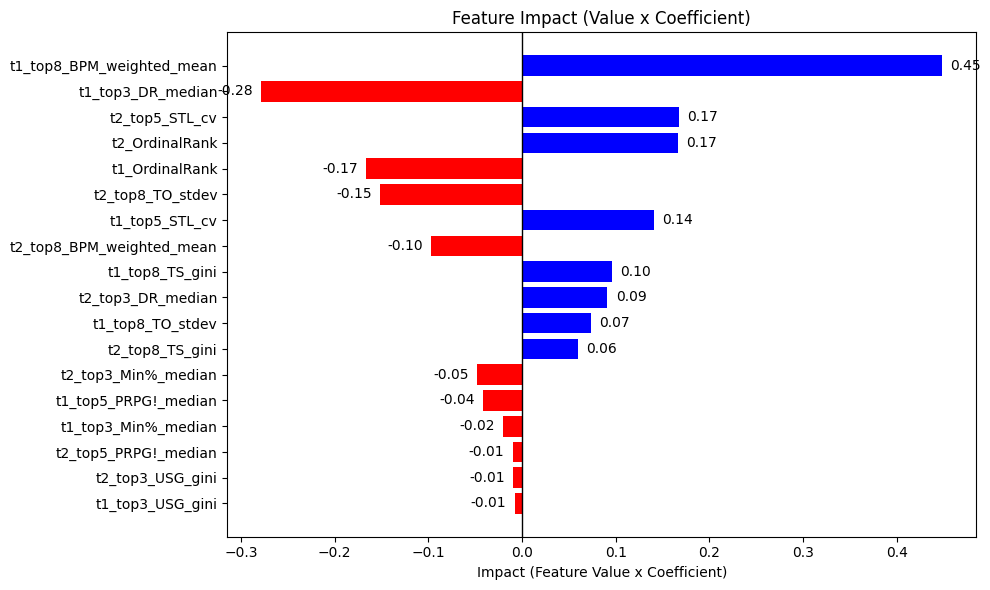

,feature_name,raw_feature_value,feature_value,model_coef,impact,abs_impact
0,t1_top8_BPM_weighted_mean,4.877177,0.585654,0.765261,0.448178,0.448178
6,t1_top3_DR_median,17.400000,1.774574,-0.156653,-0.277993,0.277993
9,t2_top5_STL_cv,0.472777,1.251702,0.133661,0.167304,0.167304
17,t2_OrdinalRank,25.000000,0.578193,0.287672,0.166330,0.166330
16,t1_OrdinalRank,25.000000,0.578193,-0.287672,-0.166330,0.166330
3,t2_top8_TO_stdev,3.423426,-0.667935,0.226199,-0.151087,0.151087
8,t1_top5_STL_cv,0.201739,-1.051507,-0.133661,0.140545,0.140545
1,t2_top8_BPM_weighted_mean,4.010468,0.126925,-0.765261,-0.097130,0.097130
12,t1_top8_TS_gini,0.077062,1.628394,0.058904,0.095919,0.095919
7,t2_top3_DR_median,14.000000,0.581799,0.156653,0.091141,0.091141


In [279]:
analyze_first_round_game("Michigan")

net weighted value: -0.29344260937621347


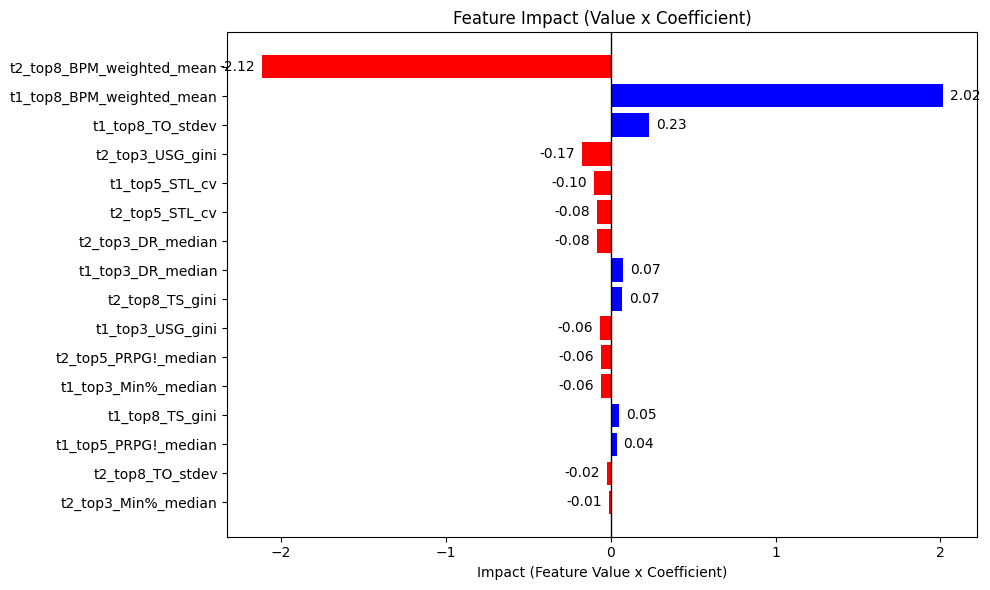

,feature_name,raw_feature_value,feature_value,model_coef,impact,abs_impact
1,t2_top8_BPM_weighted_mean,8.555080,2.144129,-0.987870,-2.118120,2.118120
0,t1_top8_BPM_weighted_mean,8.353145,2.041973,0.987870,2.017203,2.017203
2,t1_top8_TO_stdev,2.357302,-1.367650,-0.171814,0.234981,0.234981
15,t2_top3_USG_gini,0.016667,-1.508333,0.115102,-0.173613,0.173613
8,t1_top5_STL_cv,0.433588,0.971693,-0.107014,-0.103984,0.103984
9,t2_top5_STL_cv,0.230294,-0.767057,0.107014,-0.082086,0.082086
7,t2_top3_DR_median,10.300000,-0.674675,0.121538,-0.081999,0.081999
6,t1_top3_DR_median,10.500000,-0.602780,-0.121538,0.073261,0.073261
13,t2_top8_TS_gini,0.040613,-0.622307,-0.114087,0.070997,0.070997
14,t1_top3_USG_gini,0.107312,0.556586,-0.115102,-0.064064,0.064064


In [332]:
analyze_non_first_round_game("Duke", "Houston")